<a href="https://colab.research.google.com/github/EgorMatveev26/MO_Attack/blob/main/lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 5. Итеративные и оптимизационные атаки: PGD, C&W, JSMA

**Курс:** Машинное обучение. Безопасность ИИ-систем

**По материалам лекции 4**

**Формат:** индивидуально или в парах

**Среда:** Python, PyTorch, torchvision

## Цель работы
Закрепить методы построения многошаговых и оптимизационных evasion-атак и научиться сравнивать их по силе, вычислительной стоимости и величине вносимого искажения.

## Результаты обучения
После выполнения работы вы должны уметь:
- реализовывать PGD-атаку с проекцией на $L_\infty$-шар и случайным стартом;
- объяснять формулировку седловой точки (min-max) и её связь с adversarial training;
- реализовывать целевую C&W L2-атаку с заменой переменных через tanh и параметром confidence κ;
- реализовывать JSMA на основе якобиана выхода модели и точечного насыщения признаков;
- сравнивать атаки по Attack Success Rate, норме возмущения и вычислительным затратам.

## Как пользоваться этим ноутбуком
- Ячейки с `# TODO` необходимо заполнить самостоятельно.
- Ячейки с текстом **"Вопрос для отчёта"** требуют письменного ответа в markdown-ячейке ниже.
- Перед сдачей: Kernel → Restart & Run All, ноутбук должен выполняться от начала до конца без ошибок.
- Атаки на MNIST могут занимать заметное время на CPU (особенно JSMA) — рассчитывайте время выполнения заранее.


## 0. Подготовка окружения

In [4]:
# TODO: импортируйте необходимые библиотеки
# Подсказка: numpy, matplotlib, torch, torch.nn, torch.nn.functional,
# torchvision (datasets, transforms), torch.utils.data.DataLoader

import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import pandas as pd
import time

RANDOM_STATE = 42
# TODO: зафиксируйте seed для torch и numpy
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")   # TODO: определите device (cuda, если доступна, иначе cpu)
print(f"Device: {device}")

Device: cpu


## Часть I. Данные и базовая модель

**Задание:** загрузите MNIST и обучите небольшую CNN (2 свёрточных слоя + полносвязный классификатор) — эта модель станет целью для всех атак в работе.

In [5]:
# TODO: загрузите MNIST через torchvision.datasets
transform = transforms.Compose([transforms.ToTensor()])   # TODO: transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)   # TODO: batch_size=128, shuffle=True
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)    # TODO: batch_size=256, shuffle=False

100%|██████████| 9.91M/9.91M [00:00<00:00, 59.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.67MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.98MB/s]


In [6]:
import torch.nn as nn
import torch.nn.functional as F

# TODO: реализуйте класс CNN (2 свёрточных слоя, max pooling, полносвязный классификатор)
class SmallCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # 1 слой, первая свёртка, 1 входной канал, 32 выходных канала, 3 ядра (размер 3х3), паддинг 1(добавляяем по 1 пикселю по краям, чтобы при пулинге размер сохранился)
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        # 2 слой, вторая свёртка, на входе 32 признака, на выходе 64
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        # 3 слой, пулинг (сжимаем картинку, то есть из окошка 2х2(4 значения) берем максимальное одно значение)
        self.pool = nn.MaxPool2d(2, 2)
        # 4 слой, превращаем карты признаков в список важных характеристик в размере 128 штук
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        # выходной слой, из 128 чисел получаем 10 классов
        self.fc2 = nn.Linear(128, num_classes)
        # dropout для регуляризации (случайно выключаем 25% нейронов во время обучения)
        self.dropout = nn.Dropout(0.25)
    # прямой проход
    def forward(self, x):
        # первая свёртка + активация + пулинг, из 28x28 получаем 14x14
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        # вторая свёртка + активация + пулинг, из 14x14 получаем 7x7
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        # разворачиваем в вектор
        x = x.view(x.size(0), -1)
        # полносвязный слой + активация
        x = F.relu(self.fc1(x))
        # dropout
        x = self.dropout(x)
        # выходной слой
        return self.fc2(x)


In [7]:
# TODO: обучите модель на train_loader (2-3 эпохи достаточно)
# Используйте CrossEntropyLoss и Adam

model = SmallCNN().to(device)
# берем оптимизатор Adam, который будет обновлять веса, lr=0.001
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# функция потерь, измеряем насколько сеть ошиблась
criterion = nn.CrossEntropyLoss()

# одна эпоха обучения
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()        # обнуляем старые градиенты
        logits = model(x)            # прямой проход
        loss = criterion(logits, y)  # считаем ошибку
        loss.backward()              # обратный проход
        optimizer.step()             # обновляем веса
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total

for epoch in range(3):
    loss, acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    print(f"Epoch {epoch+1}: loss={loss:.4f}, train_acc={acc:.4f}")


Epoch 1: loss=0.2906, train_acc=0.9104
Epoch 2: loss=0.0733, train_acc=0.9776
Epoch 3: loss=0.0496, train_acc=0.9849


In [8]:
# TODO: оцените точность на тестовой выборке (clean accuracy)
def evaluate_accuracy(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x).argmax(1)
            correct += (pred == y).sum().item()
            total += x.size(0)
    return correct / total

clean_accuracy = evaluate_accuracy(model, test_loader, device)
print(f"Clean accuracy: {clean_accuracy:.4f}")

Clean accuracy: 0.9884


## Часть II. Projected Gradient Descent (PGD)

### 2.1. Реализация PGD

**Задание:** реализуйте функцию PGD-атаки по формуле

$ x^{t+1} = \Pi_{x+\mathcal{S}} \left( x^t + \alpha \cdot \text{sign}$nabla_x L$theta, x^t, y)) \right) $

Функция должна:
1. Инициализировать возмущение случайно внутри \$epsilon$-шара (random start).
2. На каждой итерации пересчитывать градиент и делать шаг по знаку градиента.
3. Проецировать (clip) возмущение на \$epsilon$-шар и итоговый пиксель — на диапазон $[0,1]$.

In [9]:
# TODO: реализуйте функцию PGD-атаки
def pgd_attack(model, x, y, epsilon, alpha, num_iter, criterion, randomize=True):
    model.eval()
    x_orig = x.clone().detach()

    # 1. Инициализация delta (случайная или нулевая)
    if randomize:
        delta = torch.empty_like(x).uniform_(-epsilon, epsilon)
    else:
        delta = torch.zeros_like(x)
    delta = torch.clamp(x_orig + delta, 0.0, 1.0) - x_orig
    delta.requires_grad_(True)

    # 2. Цикл на num_iter итераций:
    for _ in range(num_iter):
        # forward pass через model(x + delta)
        logits = model(x_orig + delta)
        # вычисление loss и backward
        loss = criterion(logits, y)
        grad = torch.autograd.grad(loss, delta, retain_graph=False)[0]
        with torch.no_grad():
            # обновление delta по знаку градиента
            delta.add_(alpha * grad.sign())
            # проекция на epsilon-шар (torch.clamp)
            delta.clamp_(-epsilon, epsilon)
            # проекция на допустимый диапазон [0, 1]
            delta.copy_(torch.clamp(x_orig + delta, 0.0, 1.0) - x_orig)
        # обнуление градиента
        delta.requires_grad_(True)

    return (x_orig + delta).detach()

### 2.2. Визуализация: FGSM vs PGD

**Задание:** реализуйте FGSM (для сравнения), затем на одном тестовом примере постройте adversarial-версии обоими методами при одинаковом \$epsilon$ и визуализируйте результат (3 подграфика: оригинал, FGSM, PGD) с указанием предсказаний модели.

In [10]:
# TODO: реализуйте FGSM (напоминание из предыдущей лабораторной)
# То есть при такой атаке мы берем чистую картинкуи смотрим в какую сторону ее нужно сдвинуть, чтобы сеть ошиблась сильнее всего
def fgsm_attack(model, x, y, epsilon, criterion):
    # TODO:
    # 1. Включите отслеживание градиента для x
    x_adv = x.clone().detach().requires_grad_(True)
    # 2. Прямой проход через модель
    logits = model(x_adv)
    # 3. Вычислите loss
    loss = criterion(logits, y)
    # 4. Обратный проход (backward)
    model.zero_grad()
    loss.backward()
    # 5. Постройте возмущение epsilon * sign(grad)
    grad_sign = x_adv.grad.data.sign()
    x_adv = x + epsilon * grad_sign
    # 6. Добавьте возмущение к x, ограничьте значения в [0, 1] (torch.clamp)
    x_adv = torch.clamp(x_adv, 0.0, 1.0)
    return x_adv.detach()


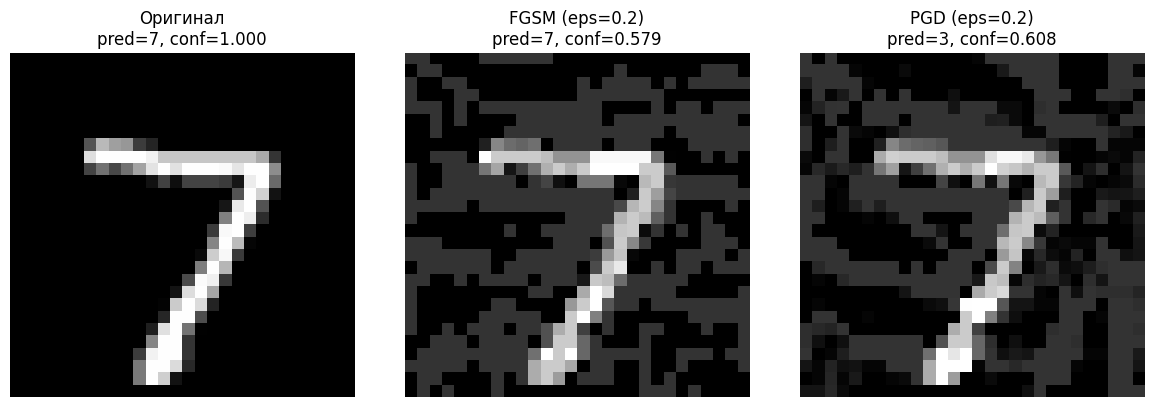

In [11]:
# TODO: выберите тестовый пример
# TODO: примените fgsm_attack и pgd_attack с epsilon=0.2 (для PGD: alpha=0.02, num_iter=40)
# TODO: постройте визуализацию из 3 подграфиков с предсказаниями модели
# найдём пример, который модель изначально классифицирует верно
model.eval()
x_sample, y_sample = None, None
for xb, yb in test_loader:
    xb, yb = xb.to(device), yb.to(device)
    preds = model(xb).argmax(dim=1)
    mask = preds == yb
    if mask.any():
        idx = mask.nonzero(as_tuple=True)[0][0]
        x_sample = xb[idx:idx+1]
        y_sample = yb[idx:idx+1]
        break

epsilon = 0.2
x_fgsm = fgsm_attack(model, x_sample, y_sample, epsilon, criterion)
x_pgd = pgd_attack(model, x_sample, y_sample, epsilon, alpha=0.02, num_iter=40, criterion=criterion)

def get_pred_and_conf(model, x):
    with torch.no_grad():
        logits = model(x)
        probs = F.softmax(logits, dim=1)
        conf, pred = probs.max(dim=1)
    return pred.item(), conf.item()

p0, c0 = get_pred_and_conf(model, x_sample)
pf, cf = get_pred_and_conf(model, x_fgsm)
pp, cp = get_pred_and_conf(model, x_pgd)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(x_sample[0, 0].cpu().numpy(), cmap="gray")
axes[0].set_title(f"Оригинал\npred={p0}, conf={c0:.3f}")
axes[1].imshow(x_fgsm[0, 0].cpu().numpy(), cmap="gray")
axes[1].set_title(f"FGSM (eps={epsilon})\npred={pf}, conf={cf:.3f}")
axes[2].imshow(x_pgd[0, 0].cpu().numpy(), cmap="gray")
axes[2].set_title(f"PGD (eps={epsilon})\npred={pp}, conf={cp:.3f}")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


**Вопрос для отчёта:** отличаются ли визуально возмущения FGSM и PGD? Какой метод успешнее меняет предсказание модели при одном и том же ε?

_Ваш ответ:_

Визуально FGSM и PGD похожи. При одинаковом eps=0.2 FGSM не сменил класс, а только снизил уверенность до 0.579. А PGD сработал лучше, так как предсказание сменилось на 3 с уверенностью 0.608, потому что делает много шагов и точнее подбирает возмущение.

### 2.3. Attack Success Rate: FGSM vs PGD

**Задание:** постройте график зависимости Attack Success Rate от бюджета $\epsilon \in \{0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3\}$ для FGSM и PGD (20 итераций) на одном графике.

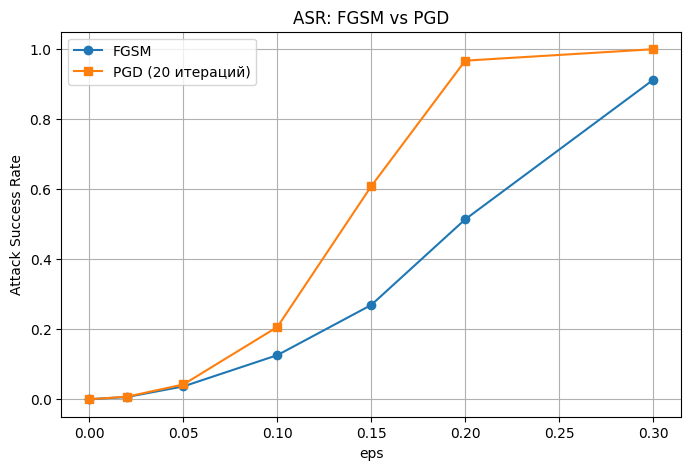

eps=0.00: FGSM=0.000, PGD=0.000
eps=0.02: FGSM=0.006, PGD=0.007
eps=0.05: FGSM=0.037, PGD=0.042
eps=0.10: FGSM=0.126, PGD=0.206
eps=0.15: FGSM=0.269, PGD=0.609
eps=0.20: FGSM=0.514, PGD=0.967
eps=0.30: FGSM=0.912, PGD=1.000


In [12]:
# TODO: реализуйте функцию оценки ASR на подмножестве тестовой выборки
# TODO: рассчитайте ASR для FGSM и PGD при каждом epsilon
# TODO: постройте сравнительный график
def evaluate_asr(model, loader, attack_fn, n_batches=10, **attack_kwargs):
    model.eval()
    total, success = 0, 0
    batch_count = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        with torch.no_grad():
            orig_preds = model(xb).argmax(dim=1)
        # рассматриваем только примеры, которые модель изначально классифицирует верно
        mask = orig_preds == yb
        if mask.sum() == 0:
            continue
        xb_ok = xb[mask]
        yb_ok = yb[mask]
        x_adv = attack_fn(model, xb_ok, yb_ok, **attack_kwargs)
        with torch.no_grad():
            adv_preds = model(x_adv).argmax(dim=1)
        success += (adv_preds != yb_ok).sum().item()
        total += yb_ok.size(0)
        batch_count += 1
        if batch_count >= n_batches:
            break
    return success / max(total, 1)

epsilons = [0.0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3]

asr_fgsm = []
asr_pgd = []
for eps in epsilons:
    if eps == 0.0:
        asr_fgsm.append(0.0)
        asr_pgd.append(0.0)
        continue
    a_f = evaluate_asr(model, test_loader, fgsm_attack, n_batches=5, epsilon=eps, criterion=criterion)
    a_p = evaluate_asr(model, test_loader, pgd_attack, n_batches=5, epsilon=eps, alpha=eps/4, num_iter=20, criterion=criterion)
    asr_fgsm.append(a_f)
    asr_pgd.append(a_p)

plt.figure(figsize=(8, 5))
plt.plot(epsilons, asr_fgsm, "o-", label="FGSM")
plt.plot(epsilons, asr_pgd, "s-", label="PGD (20 итераций)")
plt.xlabel("eps")
plt.ylabel("Attack Success Rate")
plt.title("ASR: FGSM vs PGD")
plt.grid(True)
plt.legend()
plt.show()

for eps, a_f, a_p in zip(epsilons, asr_fgsm, asr_pgd):
    print(f"eps={eps:.2f}: FGSM={a_f:.3f}, PGD={a_p:.3f}")


График показфвает долю успешных атак для двух методов при разных возмущениях. Видно, что обе атаки работают тем лучше, чем больше eps, но PGD всегда сильнее FGSM. При eps=0.2 PGD обманывает примерно 97% примеров против 51% у FGSM, то есть многошаговая атака использует бюджет возмущения гораздо эффективнее, чем одношаговая.

### 2.4. Влияние числа итераций PGD

**Задание:** зафиксируйте $\epsilon = 0.15$ и постройте график зависимости ASR от числа итераций PGD $\in \{1, 2, 5, 10, 20, 40, 80\}$. Определите, при каком числе итераций ASR стабилизируется (перестаёт заметно расти).

num_iter=1: ASR=0.041
num_iter=2: ASR=0.124
num_iter=5: ASR=0.441
num_iter=10: ASR=0.578
num_iter=20: ASR=0.610
num_iter=40: ASR=0.624
num_iter=80: ASR=0.618


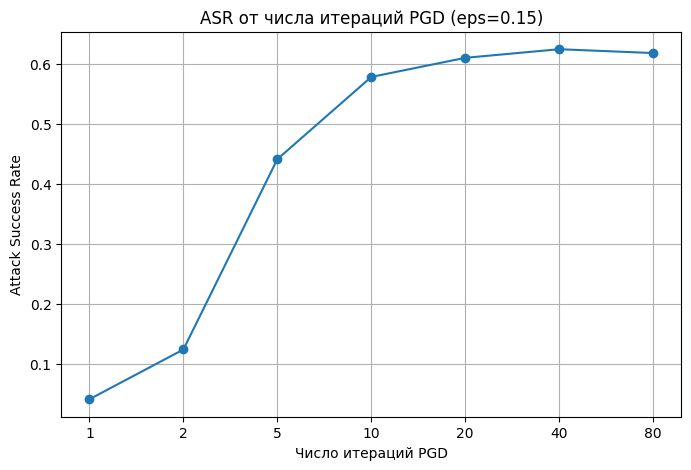

In [13]:
# TODO: рассчитайте ASR для разного числа итераций PGD при фиксированном epsilon=0.15
# TODO: постройте график

iter_list = [1, 2, 5, 10, 20, 40, 80]
asr_iters = []
eps_fixed = 0.15
for it in iter_list:
    a = evaluate_asr(model, test_loader, pgd_attack, n_batches=5, epsilon=eps_fixed, alpha=eps_fixed/4, num_iter=it, criterion=criterion)
    asr_iters.append(a)
    print(f"num_iter={it}: ASR={a:.3f}")

plt.figure(figsize=(8, 5))
plt.plot(range(len(iter_list)), asr_iters, "o-")
plt.xticks(range(len(iter_list)), iter_list)
plt.xlabel("Число итераций PGD")
plt.ylabel("Attack Success Rate")
plt.title(f"ASR от числа итераций PGD (eps={eps_fixed})")
plt.grid(True)
plt.show()

**Вопрос для отчёта:** при каком числе итераций ASR практически перестаёт расти? Как это соотносится с утверждением лекции о том, что одношаговая линеаризация (FGSM) даёт лишь нижнюю оценку силы атаки?

_Ваш ответ:_
ASR практически перестает расти примерно к 40 итерациям, дальше увеличение числа шагов почти не даёт прироста. Это значит, что PGD довольно быстро находит почти оптимальное возмущение внутри eps-шара. Утверждение лекции о том, что FGSM даёт лишь нижнюю оценку силы атаки, подтверждается, при одинаковом eps одношаговая атака стабильно слабее многошаговой, потому что делает всего один шаг из исходной точки и часто недоиспользует доступный бюджет. Многошаговость позволяет пересчитывать градиент и точнее подбирать возмущение, поэтому реальная уязвимость модели выше, чем показывает FGSM.

### 2.5. Adversarial training через PGD (седловая точка)

**Задание:** обучите вторую модель с adversarial training по формулировке седловой точки Мадри:

$\min_{\theta} \mathbb{E}_{(x,y)} \left[ \max_{\delta \in \mathcal{S}} L$theta, x+\delta, y) \right] $

На каждом шаге обучения внутренний максимум приближайте PGD с небольшим числом итераций (5-7), а внешний шаг оптимизации делайте по параметрам модели на полученных adversarial-примерах.

In [14]:
# TODO: реализуйте цикл adversarial training
# На каждом батче:
# 1. Постройте x_adv через pgd_attack (5-7 итераций, epsilon=0.15)
# 2. Посчитайте loss на x_adv
# 3. Сделайте шаг оптимизации

adv_model = SmallCNN().to(device)
opt_adv = torch.optim.Adam(adv_model.parameters(), lr=1e-3)

adv_epochs = 3
eps_train = 0.15
alpha_train = eps_train / 4
pgd_iters_train = 5

for epoch in range(adv_epochs):
    adv_model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        # 1. внутренний максимум: PGD
        x_adv = pgd_attack(adv_model, xb, yb, eps_train, alpha_train, pgd_iters_train, criterion, randomize=True)
        # 2. внешний шаг: обучение на adversarial-примерах
        adv_model.train()
        opt_adv.zero_grad()
        logits = adv_model(x_adv)
        loss = criterion(logits, yb)
        loss.backward()
        opt_adv.step()
        running_loss += loss.item() * xb.size(0)
    print(f"Adv epoch {epoch+1}/{adv_epochs}, loss={running_loss/len(train_dataset):.4f}")

adv_clean_acc = evaluate_accuracy(adv_model, test_loader, device)
print(f"Adversarial model clean accuracy: {adv_clean_acc:.4f}")


Adv epoch 1/3, loss=0.7895
Adv epoch 2/3, loss=0.3790
Adv epoch 3/3, loss=0.3089
Adversarial model clean accuracy: 0.9826


Adversarial training почти не снизил точность на чистых данных, хотя модель обучалась на зашумленных PGD-картинках.

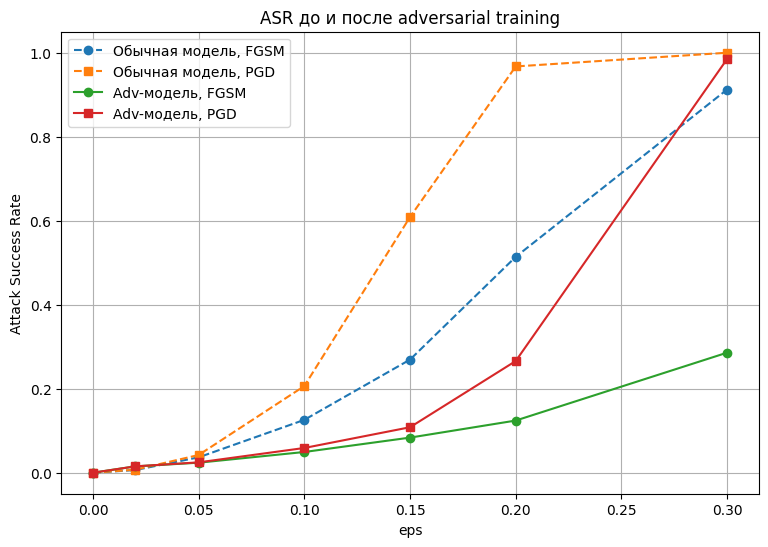

In [15]:
# TODO: постройте график ASR(epsilon) для adv_model против FGSM и против PGD
# Сравните на одном графике с результатами обычной модели из п.2.3

asr_adv_fgsm = []
asr_adv_pgd = []
for eps in epsilons:
    if eps == 0.0:
        asr_adv_fgsm.append(0.0)
        asr_adv_pgd.append(0.0)
        continue
    a_f = evaluate_asr(adv_model, test_loader, fgsm_attack, n_batches=5, epsilon=eps, criterion=criterion)
    a_p = evaluate_asr(adv_model, test_loader, pgd_attack, n_batches=5, epsilon=eps, alpha=eps/4, num_iter=20, criterion=criterion)
    asr_adv_fgsm.append(a_f)
    asr_adv_pgd.append(a_p)

plt.figure(figsize=(9, 6))
plt.plot(epsilons, asr_fgsm, "o--", label="Обычная модель, FGSM")
plt.plot(epsilons, asr_pgd, "s--", label="Обычная модель, PGD")
plt.plot(epsilons, asr_adv_fgsm, "o-", label="Adv-модель, FGSM")
plt.plot(epsilons, asr_adv_pgd, "s-", label="Adv-модель, PGD")
plt.xlabel("eps")
plt.ylabel("Attack Success Rate")
plt.title("ASR до и после adversarial training")
plt.grid(True)
plt.legend()
plt.show()

**Вопрос для отчёта:** насколько снизился ASR против PGD и против FGSM после adversarial training? Согласуется ли результат с идеей «универсального первопорядкового противника» — устойчивость к PGD переносится на устойчивость к более слабым атакам?

_Ваш ответ:_

После adversarial training ASR резко снизился. Например, при eps=0.15 против PGD он упал примерно с 0.61 до 0.11, а против FGSM с 0.27 до 0.09. При этом чистая точность модели почти не пострадала. Adv-модель, обученная на PGD, устойчива и к FGSM, хотя на нём её не тренировали, то есть защита от сильной атаки переносится на слабую. При eps=0.3 обе модели всё равно ломаются, так как устойчивость работает только в тех рамках, в которых обучали.

## Часть III. Атака Carlini & Wagner (C&W)

### 3.1. Реализация целевой C&W L2-атаки

**Задание:** реализуйте C&W-атаку (вариант L2, целевая) по следующей схеме:

1. Замена переменных: $ x' = \frac{1}{2}\tanh(w)+1) $ — гарантирует $x' \in [0,1]$ без явного clipping.
2. Функция потерь на логитах с параметром confidence κ:
$ f(x') = \max\left( \max_{i \ne t} Z(x')_i - Z(x')_t,\; -\kappa \right) $
3. Итоговая целевая функция:

$ \min_{w} \left\| \tfrac{1}{2}(\tanh(w)+1) - x \right\|_2^2 + c \cdot f\left(\tfrac{1}{2}(\tanh(w)+1)\right) $

4. Оптимизация через Adam по переменной $w$.

In [16]:
# TODO: реализуйте функцию C&W L2-атаки
    # TODO:
    # 1. Инициализируйте w = atanh(2x - 1) (с ограничением диапазона для избежания inf)
    # 2. Создайте optimizer Adam по w
    # 3. Цикл num_steps раз:
    #    - x_adv = 0.5 * (tanh(w) + 1)
    #    - получите логиты через model(x_adv)
    #    - вычислите f(x_adv) по формуле выше (max_other_logit - target_logit, ограниченный -kappa)
    #    - вычислите dist_loss = ||x_adv - x||^2
    #    - loss = dist_loss + c * f_loss
    #    - backward и шаг оптимизатора
    # 4. Верните финальный x_adv
def cw_l2_attack(model, x, target_class, c=1.0, kappa=0.0, num_steps=200, lr=0.01):
    model.eval()
    x = x.clone().detach()
    # замена переменных w = atanh(2x - 1)
    x_clamped = torch.clamp(x, 1e-6, 1 - 1e-6)
    w = torch.atanh(2 * x_clamped - 1).clone().detach().requires_grad_(True)

    optimizer = torch.optim.Adam([w], lr=lr)
    target = torch.tensor([target_class], device=x.device)

    for _ in range(num_steps):
        x_adv = 0.5 * (torch.tanh(w) + 1)
        logits = model(x_adv)
        target_logit = logits.gather(1, target.view(-1, 1)).squeeze(1)
        # маска для остальных классов
        mask = torch.ones_like(logits, dtype=torch.bool)
        mask.scatter_(1, target.view(-1, 1), False)
        other_logits = logits[mask].view(logits.size(0), -1)
        max_other = other_logits.max(dim=1)[0]
        f_loss = torch.clamp(max_other - target_logit, min=-kappa).mean()
        dist_loss = ((x_adv - x) ** 2).view(x.size(0), -1).sum(dim=1).mean()
        loss = dist_loss + c * f_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    x_adv = 0.5 * (torch.tanh(w) + 1)
    return x_adv.detach()


### 3.2. Демонстрация целевой атаки

**Задание:** выберите тестовый пример и целевой класс (отличный от истинного), постройте adversarial-пример методом C&W (κ=0) и визуализируйте: оригинал, возмущение (с указанием L2-нормы), adversarial-пример (с предсказанием и confidence).

True label: 7, target label: 0
C&W prediction: 0, confidence: 0.5764, P(target)=0.5764, L2: 3.3678
Атака успешна: True


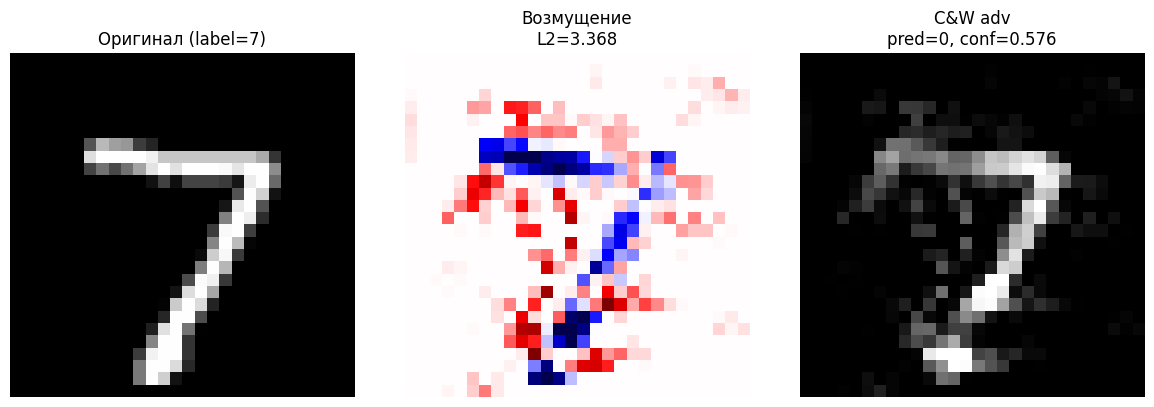

In [17]:
# TODO: выберите пример, задайте target_label
# TODO: примените cw_l2_attack
# TODO: визуализируйте результат, рассчитайте L2-норму возмущения
x_cw = x_sample.clone()
true_label = y_sample.item()  # истинная метка примера
target_label = (true_label + 3) % 10  #целевой класс(другой)
print(f"True label: {true_label}, target label: {target_label}")

# запускаем C&W L2-атаку, c=2 насколько мы сильнее хотим изменить класс, насколшько модель должна ошибиться kappa=2.5, 300 шагов, lr=0.01
x_cw_adv = cw_l2_attack(model, x_cw, target_label, c=2.0, kappa=2.5, num_steps=300, lr=0.01)

with torch.no_grad(): # без подсчёта градиентов
    pred_cw = model(x_cw_adv).argmax(dim=1).item()  # предсказание на adv-примере
    conf_cw = F.softmax(model(x_cw_adv), dim=1).max().item()  # уверенность в нем
    # вероятность именно целевого класса
    target_prob = F.softmax(model(x_cw_adv), dim=1)[0, target_label].item()

l2_norm = (x_cw_adv - x_cw).view(-1).norm(p=2).item()  # L2-норма возмущения
print(f"C&W prediction: {pred_cw}, confidence: {conf_cw:.4f}, "f"P(target)={target_prob:.4f}, L2: {l2_norm:.4f}")
print(f"Атака успешна: {pred_cw == target_label}")  # сработала ли атака

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# оригинал
axes[0].imshow(x_cw[0, 0].cpu().numpy(), cmap="gray")
axes[0].set_title(f"Оригинал (label={true_label})")

#возмущение синий уменьшили яркость, красный увеличили
pert = (x_cw_adv - x_cw)[0, 0].cpu().numpy()
axes[1].imshow(pert, cmap="seismic", vmin=-0.5, vmax=0.5)
axes[1].set_title(f"Возмущение\nL2={l2_norm:.3f}")

# adversarial-пример с предсказанием и уверенностью
axes[2].imshow(x_cw_adv[0, 0].cpu().numpy(), cmap="gray")
axes[2].set_title(f"C&W adv\npred={pred_cw}, conf={conf_cw:.3f}")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


C&W-атака успешно перевела цифру 7 в целевой класс 0 с уверенностью 0.576. L2-норма возмущения составила 3.37 (то есть 3.37 от 28 это ~ 12%), что объясняется большой геометрической разностью между этими классами и параметром k=2.5, требующим запаса уверенности в 2.5 логита.

### 3.3. Влияние параметра confidence κ

**Задание:** для того же примера постройте C&W-атаки с κ ∈ {0, 5, 10, 20, 40} и постройте два графика: (а) зависимость L2-нормы возмущения от κ, (б) зависимость вероятности целевого класса от κ.

k=0: L2=3.0271, P(target)=0.2267
k=5: L2=3.3678, P(target)=0.5764
k=10: L2=3.3678, P(target)=0.5764
k=20: L2=3.3678, P(target)=0.5764
k=40: L2=3.3678, P(target)=0.5764


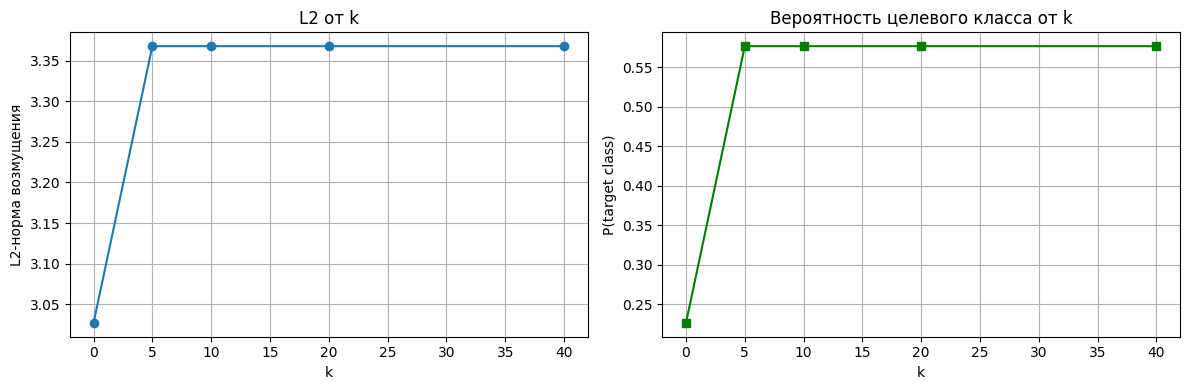

In [18]:
# TODO: постройте атаки для разных значений kappa
# TODO: постройте два графика (L2-норма и confidence целевого класса от kappa)
kappas = [0, 5, 10, 20, 40]
l2_norms = []
target_probs = []

for k in kappas:
    x_adv = cw_l2_attack(model, x_cw, target_label, c=2.0, kappa=k, num_steps=300, lr=0.01)
    l2 = (x_adv - x_cw).view(-1).norm(p=2).item()
    with torch.no_grad():
        prob = F.softmax(model(x_adv), dim=1)[0, target_label].item()
    l2_norms.append(l2)
    target_probs.append(prob)
    print(f"k={k}: L2={l2:.4f}, P(target)={prob:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(kappas, l2_norms, "o-")
axes[0].set_xlabel("k")
axes[0].set_ylabel("L2-норма возмущения")
axes[0].set_title("L2 от k")
axes[0].grid(True)

axes[1].plot(kappas, target_probs, "s-", color="green")
axes[1].set_xlabel("k")
axes[1].set_ylabel("P(target class)")
axes[1].set_title("Вероятность целевого класса от k")
axes[1].grid(True)
plt.tight_layout()
plt.show()


По первому графику смотрим насколько сильно изменилась картинка. При k=0 картинка не сильно испорчена(средне), а при k=5 картинка испорчена сильно и дальше ровная линия, так как уже есть большой запас уверенности. По второму графику смотрим вероятность целевого класса, тоже самое после k=5 вероятность отнесения к целевому классу 57%.

**Вопрос для отчёта:** как изменяется величина возмущения при росте κ? Объясните этот эффект, опираясь на формулу функции потерь $f(x')$ из лекции.

_Ваш ответ:_

Чем больше k, тем сильнее атака должна раздвинуть классы, поэтому возмущение должно расти. При k=0 достаточно, чтобы целевой класс чуть-чуть обогнал остальные, возмущение минимально. L2-норма возмущения выросла только при переходе от k=0 к k=5, а дальше не менялась. Значит, атака нашла решение с очень большим запасом, и все k до 40 оказались ниже этого порога.

## Часть IV. Jacobian-based Saliency Map Attack (JSMA)

### 4.1. Реализация JSMA

**Задание:** реализуйте целевую JSMA-атаку по следующей схеме:

1. Вычислите якобиан выходных вероятностей модели по входу (для всех 10 классов).
2. Постройте saliency-карту: произведение градиента целевого класса и (с обратным знаком) суммарного градиента остальных классов, отбирая только те пиксели, где рост значения пикселя увеличивает вероятность целевого класса и одновременно уменьшает вероятность остальных.
3. На каждой итерации выберите пиксель с максимальной saliency, "насытите" его значение (увеличьте до предела, например, на величину θ=1.0), исключите уже изменённые и предельные пиксели из дальнейшего рассмотрения.
4. Повторяйте, пока не будет достигнута целевая классификация или не будет исчерпан лимит `max_pixels`.

In [19]:
# TODO: реализуйте функцию вычисления якобиана
    # TODO:
    # Для каждого класса c вычислите градиент softmax-вероятности класса c по входу x
    # (используйте torch.autograd.grad с grad_outputs, задающим "единицу" на позиции c)
    # Соберите градиенты в тензор формы (num_classes, *x.shape[1:])
def compute_jacobian(model, x, num_classes=10):
    """x: (1, C, H, W). Возвращает тензор (num_classes, C, H, W)."""
    model.eval()
    x = x.clone().detach().requires_grad_(True)
    logits = model(x)
    probs = F.softmax(logits, dim=1)
    grads = []
    for c in range(num_classes):
        grad_outputs = torch.zeros_like(probs)
        grad_outputs[0, c] = 1.0
        grad = torch.autograd.grad(probs, x, grad_outputs=grad_outputs,
                                   retain_graph=True)[0]
        grads.append(grad[0])  # (C, H, W)
    return torch.stack(grads, dim=0)  # (num_classes, C, H, W)


In [20]:
# TODO: реализуйте функцию JSMA-атаки
    # TODO:
    # 1. Скопируйте x в x_adv, создайте маску modified (по форме одного изображения, без батча)
    # 2. Цикл до max_pixels раз:
    #    - проверьте текущее предсказание модели, выйдите, если совпадает с target_class
    #    - вычислите якобиан через compute_jacobian
    #    - target_grad = якобиан для целевого класса
    #    - other_grad = сумма якобианов остальных классов
    #    - saliency = target_grad * (other_grad < 0) * |other_grad|
    #    - исключите уже изменённые и насыщенные (>=0.99) пиксели из saliency (установите -inf)
    #    - найдите индекс пикселя с максимальной saliency
    #    - увеличьте значение этого пикселя на theta (не более 1.0), отметьте как изменённый
    # 3. Верните x_adv и число изменённых пикселей
def jsma_attack(model, x, target_class, max_pixels=60, theta=1.0):
    model.eval()
    x_adv = x.clone().detach()
    # маска изменённых пикселей (по одному изображению)
    modified = torch.zeros_like(x_adv[0], dtype=torch.bool)
    n_changed = 0

    for _ in range(max_pixels):
        with torch.no_grad():
            pred = model(x_adv).argmax(dim=1).item()
        if pred == target_class:
            break

        jacobian = compute_jacobian(model, x_adv)  # (10, C, H, W)
        target_grad = jacobian[target_class]       # (C, H, W)

        # сумма градиентов остальных классов
        other_grad = torch.zeros_like(target_grad)
        for c in range(jacobian.size(0)):
            if c != target_class:
                other_grad += jacobian[c]

        # рост target_grad>0 и уменьшение other_grad<0
        saliency = target_grad * (other_grad < 0).float() * other_grad.abs()
        # исключаем уже изменённые и насыщенные пиксели
        saliency = saliency.clone()
        saliency[modified] = -float("inf")
        saliency[(x_adv[0] >= 0.99)] = -float("inf")

        if torch.isinf(saliency).all():
            break

        flat_idx = saliency.view(-1).argmax().item()
        # переводим плоский индекс в (C, H, W)
        c_idx = flat_idx // (x_adv.size(2) * x_adv.size(3))
        rem = flat_idx % (x_adv.size(2) * x_adv.size(3))
        h_idx = rem // x_adv.size(3)
        w_idx = rem % x_adv.size(3)

        with torch.no_grad():
            new_val = min(1.0, x_adv[0, c_idx, h_idx, w_idx].item() + theta)
            x_adv[0, c_idx, h_idx, w_idx] = new_val
        modified[0, h_idx, w_idx] = True
        n_changed += 1

    return x_adv.detach(), n_changed


### 4.2. Демонстрация точечной атаки

**Задание:** для того же примера и целевого класса, что и в п.3.2, постройте JSMA-атаку и визуализируйте: оригинал, карту изменённых пикселей, adversarial-пример (с предсказанием модели и числом изменённых пикселей).

JSMA prediction: 0, confidence: 0.2670, изменено пикселей: 33


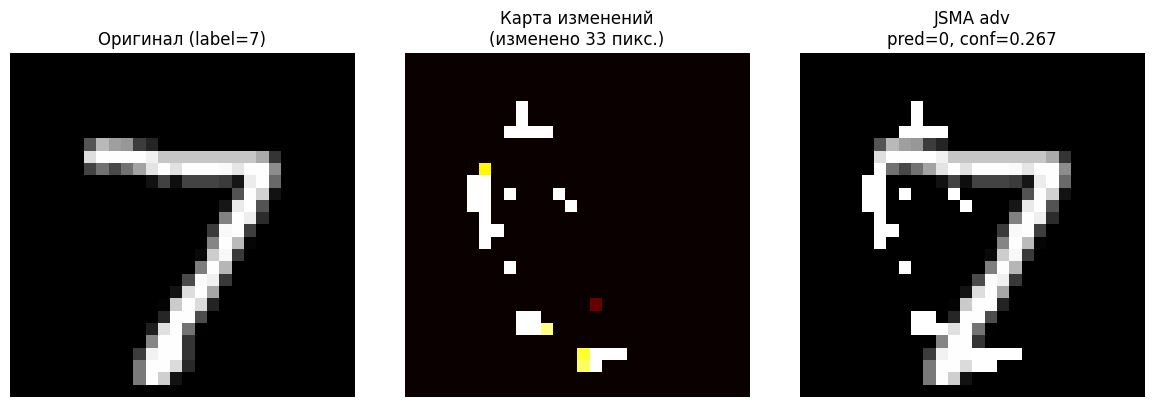

In [21]:
# TODO: примените jsma_attack к тому же примеру и target_label из части III
# TODO: визуализируйте результат (3 подграфика)
x_jsma_adv, n_pixels = jsma_attack(model, x_cw, target_label, max_pixels=100, theta=1.0)

with torch.no_grad():
    pred_jsma = model(x_jsma_adv).argmax(dim=1).item()
    conf_jsma = F.softmax(model(x_jsma_adv), dim=1).max().item()

print(f"JSMA prediction: {pred_jsma}, confidence: {conf_jsma:.4f}, изменено пикселей: {n_pixels}")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(x_cw[0, 0].cpu().numpy(), cmap="gray")
axes[0].set_title(f"Оригинал (label={true_label})")

# карта изменённых пикселей
diff_map = (x_jsma_adv - x_cw).abs().sum(dim=1)[0].cpu().numpy()
axes[1].imshow(diff_map, cmap="hot")
axes[1].set_title(f"Карта изменений\n(изменено {n_pixels} пикс.)")

axes[2].imshow(x_jsma_adv[0, 0].cpu().numpy(), cmap="gray")
axes[2].set_title(f"JSMA adv\npred={pred_jsma}, conf={conf_jsma:.3f}")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


**Вопрос для отчёта:** сколько пикселей потребовалось изменить для успешной атаки? Насколько это число мало по сравнению с общим числом пикселей изображения (28×28=784)?

_Ваш ответ:_

JSMA потребовалось изменить всего 33 пикселя из 784 это около 4% от всей картинки. Это очень мало по сравнению с PGD и C&W, которые меняют почти все пиксели. Главное преимущество JSMA, в том что она находит несколько самых влиятельных пикселей и меняет только их.

## Часть V. Итоговое сравнение атак

**Задание:** для одного и того же исходного изображения и целевого класса постройте атаки всеми тремя методами (целевой PGD, C&W, JSMA) и сравните их в таблице по следующим критериям:
- успешность (достигнут ли целевой класс);
- L2-норма возмущения;
- L∞-норма возмущения;
- число изменённых пикселей (порог изменения > 1e-3).

Постройте также столбчатую диаграмму, сравнивающую три атаки по каждому из трёх числовых критериев.

In [22]:
# TODO: реализуйте функцию целевой PGD-атаки (минимизация loss к целевому классу вместо максимизации к истинному)
def pgd_targeted(model, x, target, epsilon, alpha, num_iter, criterion):
    model.eval()
    x_orig = x.clone().detach()
    delta = torch.empty_like(x).uniform_(-epsilon, epsilon)
    delta = torch.clamp(x_orig + delta, 0.0, 1.0) - x_orig
    delta.requires_grad_(True)
    target_tensor = torch.tensor([target], device=x.device)

    for _ in range(num_iter):
        logits = model(x_orig + delta)
        # минимизируем loss к целевому классу
        loss = criterion(logits, target_tensor)
        grad = torch.autograd.grad(loss, delta)[0]
        with torch.no_grad():
            delta.add_(-alpha * grad.sign())  # шаг в сторону уменьшения loss
            delta.clamp_(-epsilon, epsilon)
            delta.copy_(torch.clamp(x_orig + delta, 0.0, 1.0) - x_orig)
        delta.requires_grad_(True)

    return (x_orig + delta).detach()


In [23]:
# TODO: постройте атаки всеми тремя методами для одного примера и одного target_label
# TODO: соберите результаты в pandas DataFrame (метод, успех, предсказание, L2, Linf, число пикселей)
# TODO: сохраните таблицу в CSV
def count_changed_pixels(x_orig, x_adv, thresh=1e-3):
    diff = (x_adv - x_orig).abs().sum(dim=1)[0]
    return (diff > thresh).sum().item()

results = []
# PGD
x_pgd_t = pgd_targeted(model, x_cw, target_label, epsilon=0.3, alpha=0.03, num_iter=40, criterion=criterion)
with torch.no_grad():
    pred = model(x_pgd_t).argmax(dim=1).item()
l2 = (x_pgd_t - x_cw).view(-1).norm(p=2).item()
linf = (x_pgd_t - x_cw).view(-1).abs().max().item()
n_pix = count_changed_pixels(x_cw, x_pgd_t)
results.append({"method": "PGD (targeted)", "success": pred == target_label, "pred": pred, "L2": l2, "Linf": linf, "n_pixels": n_pix})

# C&W
x_cw_adv2 = cw_l2_attack(model, x_cw, target_label, c=2.0, kappa=2.5, num_steps=300, lr=0.01)
with torch.no_grad():
    pred = model(x_cw_adv2).argmax(dim=1).item()
l2 = (x_cw_adv2 - x_cw).view(-1).norm(p=2).item()
linf = (x_cw_adv2 - x_cw).view(-1).abs().max().item()
n_pix = count_changed_pixels(x_cw, x_cw_adv2)
results.append({"method": "C&W L2", "success": pred == target_label, "pred": pred, "L2": l2, "Linf": linf, "n_pixels": n_pix})

# JSMA
x_jsma_adv2, n_pix_jsma = jsma_attack(model, x_cw, target_label, max_pixels=100, theta=1.0)
with torch.no_grad():
    pred = model(x_jsma_adv2).argmax(dim=1).item()
l2 = (x_jsma_adv2 - x_cw).view(-1).norm(p=2).item()
linf = (x_jsma_adv2 - x_cw).view(-1).abs().max().item()
n_pix = count_changed_pixels(x_cw, x_jsma_adv2)
results.append({"method": "JSMA", "success": pred == target_label, "pred": pred, "L2": l2, "Linf": linf, "n_pixels": n_pix})

df = pd.DataFrame(results)
print(df.to_string(index=False))
df.to_csv("attack_comparison.csv", index=False)

        method  success  pred       L2    Linf  n_pixels
PGD (targeted)     True     0 5.773633 0.30000       511
        C&W L2     True     0 3.367842 0.76123       314
          JSMA     True     0 5.538929 1.00000        33


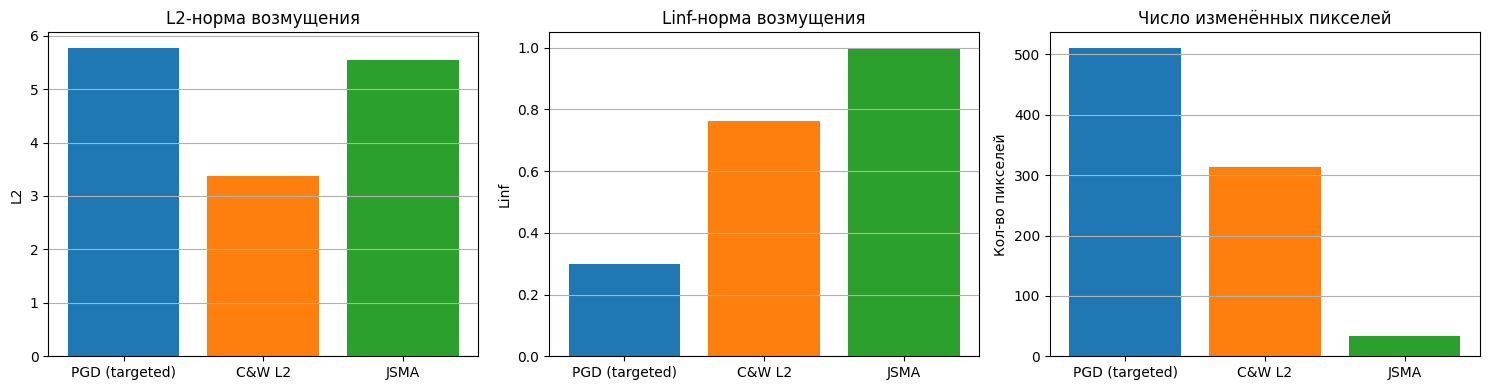

In [24]:
# TODO: постройте столбчатую диаграмму из 3 подграфиков (L2, Linf, число изменённых пикселей)
# для трёх методов
# TODO: постройте столбчатую диаграмму из 3 подграфиков
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
methods = df["method"].tolist()
colors = ["tab:blue", "tab:orange", "tab:green"]

axes[0].bar(methods, df["L2"], color=colors)
axes[0].set_title("L2-норма возмущения")
axes[0].set_ylabel("L2")
axes[1].bar(methods, df["Linf"], color=colors)
axes[1].set_title("Linf-норма возмущения")
axes[1].set_ylabel("Linf")
axes[2].bar(methods, df["n_pixels"], color=colors)
axes[2].set_title("Число изменённых пикселей")
axes[2].set_ylabel("Кол-во пикселей")
for ax in axes:
    ax.grid(True, axis="y")
plt.tight_layout()
plt.show()

**Вопрос для отчёта:** какой метод дал наименьшую L2-норму возмущения? Какой — наименьшее число изменённых пикселей? Объясните разницу, опираясь на то, какую норму возмущения оптимизирует каждый метод по своей природе.

_Ваш ответ:_

Наименьшую L2-норму дала C&W около 3.4 против 5.6 у JSMA и 5.7 у PGD. Это ожидаемо, так как C&W явно минимизирует L2-норму (суммарную силу изменений по всем пикселям) в своей целевой функции. Наименьшее число изменённых пикселей дала JSMA около 40 против 310 у C&W и 510 у PGD. JSMA по своей природе оптимизирует L0-норму (число изменённых пикселей), меняя только самые влиятельные точки. Целевой PGD, наоборот, показал наименьший Linf (0.3), потому что оптимизирует именно Linf-бюджет, то есть жёстко ограничивает максимальное отклонение каждого пикселя. Таким образом, каждая атака выигрывает в той метрике, которую она минимизирует по построению, и проигрывает в остальных.

## Часть VI. Итоговый вывод

**Вопрос для отчёта:** сформулируйте общий вывод о трёх изученных методах атак. Почему PGD считается «универсальным первопорядковым противником» и стандартом для adversarial training, тогда как C&W чаще используется как эталон для проверки устойчивости защитных механизмов, а JSMA — как инструмент, ценный своей интерпретируемостью и разреженностью возмущения? В каких прикладных сценариях (например, атаки на изображения высокого разрешения, на табличные данные, на системы обнаружения вторжений) предпочтителен каждый из методов?

_Ваш ответ:_

Все три атаки заставляют модель ошибаться, но по-разному. PGD делает много маленьких шагов по градиенту и поэтому считается универсальным противником и стандартом для adversarial training и если модель устойчива к нему, она устойчива и к более слабым атакам. C&W прямо минимизирует L2-норму и даёт самые незаметные изменения, поэтому используется как эталон для проверки защит. JSMA меняет минимум пикселей и ценна своей разреженностью и интерпретируемостью. Для изображений высокого разрешения подходят PGD и C&W, для табличных данных и систем обнаружения вторжений JSMA, а для проверки защит C&W и PGD.

---
Выполните **не менее двух** из следующих заданий. Оформите результаты в отдельных ячейках ниже с пометкой `# ДЛЯ СИЛЬНЫХ СТУДЕНТОВ`.

### С1. PGD с разными нормами
Реализуйте вариант PGD-атаки с проекцией на $L_2$-шар вместо $L_\infty$ (нормализация градиента по L2-норме на каждом шаге с последующим масштабированием под бюджет ε). Сравните визуально и по ASR с исходным $L_\infty$-вариантом.

### С2. Ускоренная (Maximal) JSMA
Изучите идею ускоренных версий JSMA (например, приближение сложности с $O(M^2 N)$ до $O(M\sqrt{N})$ за счёт эвристического отбора кандидатов вместо полного перебора). Реализуйте упрощённую версию с случайной подвыборкой кандидатов на каждой итерации и сравните скорость и качество атаки с полной версией из Части IV.

### С3. Перенос устойчивости между атаками (adversarial training cross-attack)
Обучите модель с adversarial training на PGD (Часть 2.5). Проверьте её устойчивость не только к PGD и FGSM, но и к C&W и JSMA. Обсудите, перенеслась ли устойчивость на оптимизационные и разреженные атаки, которые не участвовали в обучении.

### С4. Влияние константы c в C&W
Исследуйте, как выбор константы $c$ в целевой функции C&W (без бинарного поиска, вручную для нескольких значений: 0.1, 1, 10, 100) влияет на баланс между успешностью атаки и величиной L2-искажения. Постройте график Success Rate и средней L2-нормы в зависимости от $c$ на нескольких тестовых примерах.


eps=0.02: Linf PGD=0.007, L2 PGD=0.000
eps=0.05: Linf PGD=0.043, L2 PGD=0.000
eps=0.1: Linf PGD=0.207, L2 PGD=0.001
eps=0.15: Linf PGD=0.607, L2 PGD=0.003
eps=0.2: Linf PGD=0.971, L2 PGD=0.006
eps=0.3: Linf PGD=1.000, L2 PGD=0.015


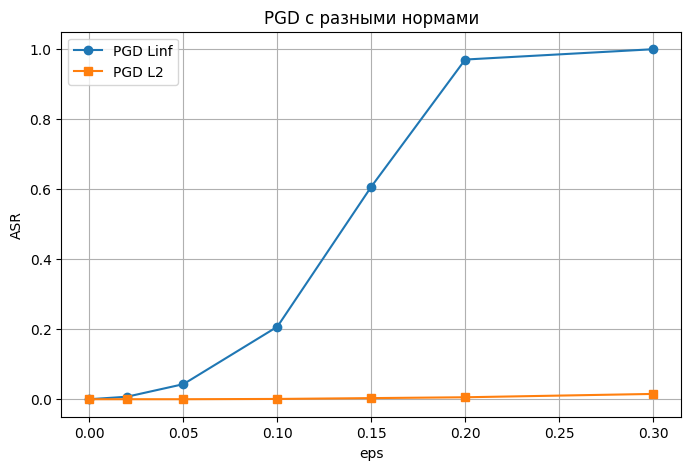

In [25]:
# ДЛЯ СИЛЬНЫХ СТУДЕНТОВ
# С1 (PGD с разными нормами)

def pgd_l2_attack(model, x, y, epsilon, alpha, num_iter, criterion, randomize=True):
    model.eval()
    x_orig = x.clone().detach()
    if randomize:
        delta = torch.randn_like(x)
        delta = delta / delta.view(delta.size(0), -1).norm(p=2, dim=1).view(-1,1,1,1) * epsilon * torch.rand(x.size(0),1,1,1, device=x.device)
    else:
        delta = torch.zeros_like(x)
    delta = torch.clamp(x_orig + delta, 0, 1) - x_orig
    delta.requires_grad_(True)

    for _ in range(num_iter):
        logits = model(x_orig + delta)
        loss = criterion(logits, y)
        grad = torch.autograd.grad(loss, delta)[0]
        with torch.no_grad():
            # нормализация градиента по L2
            g_norm = grad.view(grad.size(0), -1).norm(p=2, dim=1).view(-1,1,1,1) + 1e-12
            delta.add_(alpha * grad / g_norm)
            # проекция на L2-шар радиуса epsilon
            d_norm = delta.view(delta.size(0), -1).norm(p=2, dim=1).view(-1,1,1,1)
            factor = torch.clamp(epsilon / (d_norm + 1e-12), max=1.0)
            delta.mul_(factor)
            delta.copy_(torch.clamp(x_orig + delta, 0, 1) - x_orig)
        delta.requires_grad_(True)
    return (x_orig + delta).detach()

# Сравнение ASR
asr_pgd_linf = []
asr_pgd_l2 = []
for eps in epsilons:
    if eps == 0.0:
        asr_pgd_linf.append(0.0)
        asr_pgd_l2.append(0.0)
        continue
    a1 = evaluate_asr(model, test_loader, pgd_attack, n_batches=5, epsilon=eps, alpha=eps/4, num_iter=20, criterion=criterion)
    a2 = evaluate_asr(model, test_loader, pgd_l2_attack, n_batches=5, epsilon=eps, alpha=eps/4, num_iter=20, criterion=criterion)
    asr_pgd_linf.append(a1)
    asr_pgd_l2.append(a2)
    print(f"eps={eps}: Linf PGD={a1:.3f}, L2 PGD={a2:.3f}")

plt.figure(figsize=(8,5))
plt.plot(epsilons, asr_pgd_linf, "o-", label="PGD Linf")
plt.plot(epsilons, asr_pgd_l2, "s-", label="PGD L2")
plt.xlabel("eps")
plt.ylabel("ASR")
plt.grid(True)
plt.legend()
plt.title("PGD с разными нормами")
plt.show()

Linf-PGD (ограничение пикселя бюджетом eps) работает как надо, ASR растёт с 0 до 1 по мере увеличения eps, и при eps=0.2 уже достигает 97%. L2-PGD (ограничение суммарное) практически не атакует, ASR остаётся близким к нулю на всём диапазоне eps, максимум 0.015 при eps=0.3.

In [26]:
# С4 (Влияние константы c в C&W)

c_values = [0.1, 1, 10, 100]
# возьмём несколько примеров
n_examples = 5
examples = []
for xb, yb in test_loader:
    xb, yb = xb.to(device), yb.to(device)
    preds = model(xb).argmax(dim=1)
    mask = preds == yb
    for i in mask.nonzero(as_tuple=True)[0][:n_examples]:
        examples.append((xb[i:i+1], yb[i:i+1]))
        if len(examples) >= n_examples:
            break
    if len(examples) >= n_examples:
        break

for c_val in c_values:
    successes, l2s = 0, []
    for x_e, y_e in examples:
        target = (y_e.item() + 3) % 10
        x_adv = cw_l2_attack(model, x_e, target, c=c_val, kappa=0, num_steps=200, lr=0.01)
        with torch.no_grad():
            pred = model(x_adv).argmax(dim=1).item()
        if pred == target:
            successes += 1
            l2s.append((x_adv - x_e).view(-1).norm(p=2).item())
    sr = successes / len(examples)
    mean_l2 = np.mean(l2s) if l2s else 0.0
    print(f"c={c_val}: Success Rate={sr:.2f}, mean L2={mean_l2:.4f}")

c=0.1: Success Rate=0.00, mean L2=0.0000
c=1: Success Rate=0.40, mean L2=2.3379
c=10: Success Rate=1.00, mean L2=3.5127
c=100: Success Rate=1.00, mean L2=4.0838


 При c=0.1 атака вообще не срабатывает, при c=1 срабатывает в 40% случаев, а при c=10 и c=100 всегда. Но чем больше c, тем сильнее портится картинка, L2 растёт с 2.34 до 4.08. c это баланс между успехом и незаметностью, а оптимальное значение около c=10, так как атака уже всегда успешна, но возмущение ещё не слишком большое.

---

## Требования к сдаче
- Ноутбук выполняется целиком без ошибок (Kernel → Restart & Run All).
- Все `# TODO` заполнены, все вопросы для отчёта содержат письменный ответ.
- Обязательны: реализация PGD с проекцией, реализация C&W с замерами κ, реализация JSMA на основе якобиана, итоговая сравнительная таблица трёх атак.
